In [1]:
using Revise
includet("../../scripts/single_influx.jl")

In [2]:
using ProgressMeter
using ColorSchemes
using UnPack

In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

## Generate data

In [27]:
N = M = 20
B = 3
Ks = 10 .^ range(-0.5, 4.0, 20)

pe = B / M

df, cms = do_df_run(Ks, N;
    M,
    ### Slightly random bits
    m=base10_lognormal(0., 0.001),
    c=base10_lognormal(0., 0.001),
    cinflux=base10_lognormal(0., 0.001),
    num_byproducts=Binomial(M, pe),
    ### Diffusions
    Ds=0.,
    Dr=1.,
    ### Influx bits
    pei=1.0,
    linflux=1.,
    ### Non-influx bits
    pe=pe,
    l=0.0,
    ### Technical bits
    num_repeats=100,
    lsks=10 .^ range(-5, 3, 2000),
);

Progress:  30%|████████████▎                            |  ETA: 0:02:07┌ Warning: At t=2501.6170333767, dt was forced below floating point epsilon 4.547473508864641e-13, and step error estimate = 0.0004176328474472248. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:673
┌ Error: maxresid reached is 9.93617e+22 which is above the error threshold of 1e-08
└ @ SSMCMain.ModifiedMiCRM.RandomSystems ~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode/src/SSMCMain/src/ModifiedMiCRM/RandomSystems/RandomSystems.jl:400
Progress:  35%|██████████████▍                          |  ETA: 0:02:28┌ Warning: At t=199.21738348374907, dt was forced below floating point epsilon 2.842170943040401e-14, and step error estimate = 0.0001842358805996978. Aborting. There is either an error in your model speci

countmap(df.sscode) = Dict(1015 => 1, 2 => 671, -2000 => 31, 1 => 1297)
countmap(df.lscode) = Dict{Union{Missing, Int64}, Int64}(missing => 32, 2 => 979, 1 => 966, 23 => 23)
count($(Expr(:.&&, :(df.good_ss), :(df.good_ls)))) / nrow(df) = 0.9725
prop_good_ss_and_ls = 0.9725


In [28]:
cdf = make_counts_df(df);

In [29]:
jldsave("../../data/forfigures/fig1/si_li3.jld2"; N, M, B, Ks, df, cdf, cms)

## Make the plot V2 (no biomass choose 4 ls)

In [30]:
f = jldopen("../../data/forfigures/fig1/si_li3.jld2")
@unpack Ks, df, cdf = f

JLDFile /home/honza/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode/data/forfigures/fig1/si_li3.jld2 (read-only)
 ├─🔢 N
 ├─🔢 M
 ├─🔢 B
 ├─🔢 Ks
 ├─🔢 df
 ├─🔢 cdf
 └─🔢 cms

## Plot a sample SI dispersion relation

In [5]:
f = jldopen("./figures_data/si_li1.jld2")
@unpack Ks, df, cdf = f

JLDFile /home/honza/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode/notebooks/clean slate/figures_data/si_li1.jld2 (read-only)
 ├─🔢 N
 ├─🔢 M
 ├─🔢 B
 ├─🔢 Ks
 ├─🔢 df
 ├─🔢 cdf
 └─🔢 cms

In [6]:
cK = Ks[9]
@show cK
xx = @subset df :K .== cK :lscode .== 2
@show nrow(xx)
# yy = rand(eachrow(xx));
yy = xx[1,:];

cK = 10.0
nrow(xx) = 86


[ Info: Unstable, mrl is 0.0138155


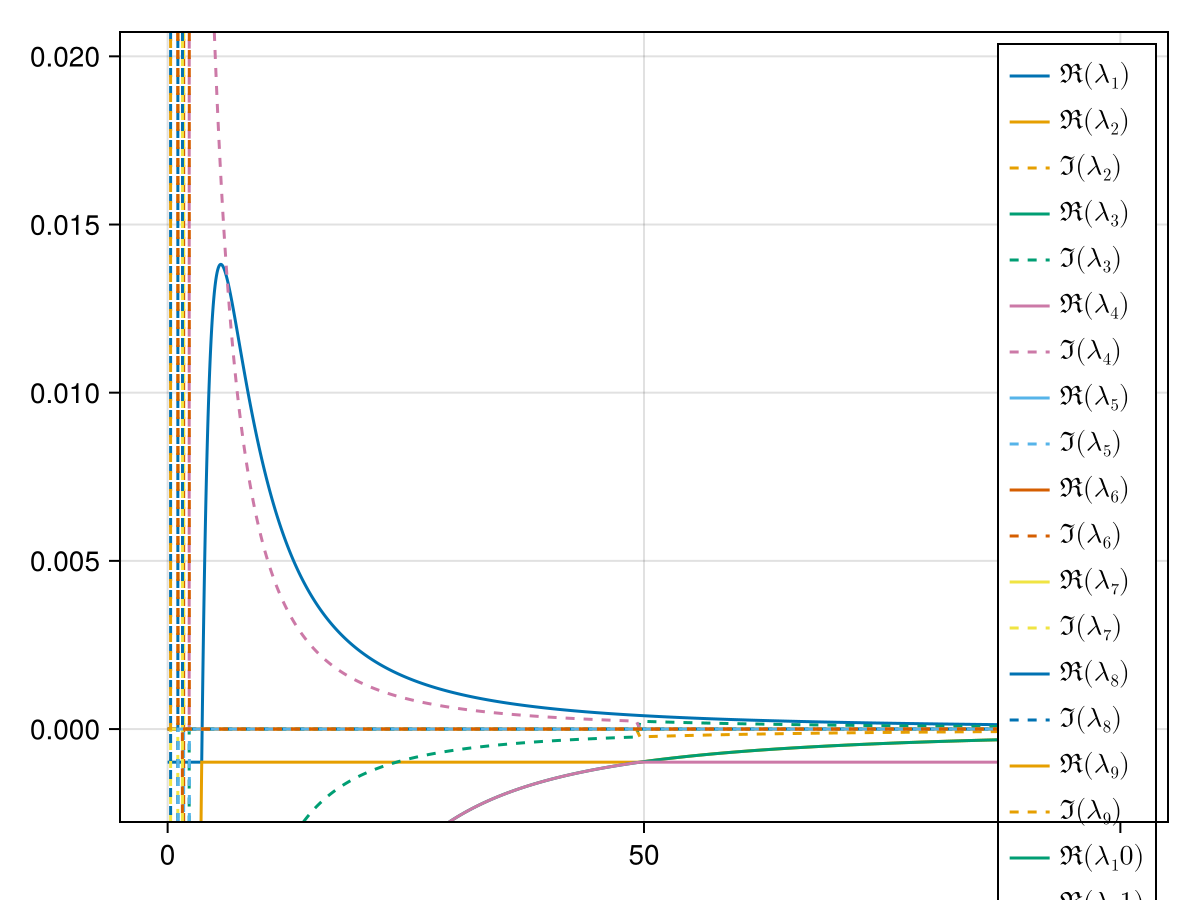

In [7]:
ks = 10 .^ range(-5, 2, 2000)
lsfunc = linstab_make_k_func(yy.params, yy.steadystates)
lambdas = lsfunc.(ks)
faa = plot_linstab_lambdas(ks, lambdas)
# display(GLMakie.Screen(), faa.figure)
faa.figure

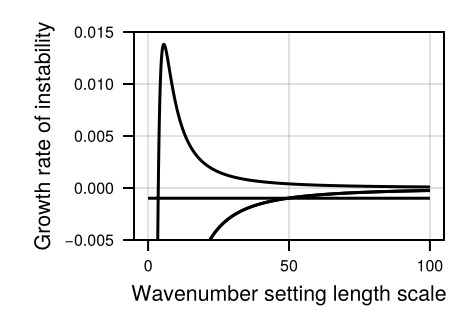

In [10]:
fig = Figure(;
    size=(double_col_width * 0.35, 0.4 * double_col_width / golden_ratio),
    fontsize=8fontsize_pt,
)
ax = Axis(fig[1,1];
    xlabel="Wavenumber setting length scale",
    ylabel="Growth rate of instability",
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
    # ylabel=L"\lambda,\enspace\text{growth rate}",
    # xlabel=L"k,\enspace\text{wavenumber}",
)

num_lambdas = length(lambdas[1])

for li in 1:num_lambdas
    ls = getindex.(lambdas, li)

    lines!(ax, ks, real(ls);
        color=:black,
    )
end

ylims!(ax, -0.005, 0.015)

Makie.save("../../figures/fig1/disprel_si_sample.pdf", fig)

fig

In [87]:
fig = Figure(;
    size=(double_col_width * 0.4, 0.4 * double_col_width / golden_ratio),
    fontsize=8*(4/3),
)
ax = Axis(fig[1,1];
    xlabel="wavenumber setting lengthscale",
    ylabel="Growth rate\nof instability",
    # xlabelsize=(4/3)*8,
    # ylabelsize=(4/3)*8,
    yticklabelsize=:small,
    # ylabel=L"\lambda,\enspace\text{growth rate}",
    # xlabel=L"k,\enspace\text{wavenumber}",
)

num_lambdas = length(lambdas[1])

for li in 1:num_lambdas
    ls = getindex.(lambdas, li)

    lines!(ax, ks, real(ls);
        color=Cycled(li),
    )
end

ylims!(ax, -0.005, 0.01)

Makie.save("../../figures/fig1/disprel_si_sample.pdf", fig)

fig

LoadError: MethodError: [0mCannot `convert` an object of type [92mSymbol[39m[0m to an object of type [91mFloat64[39m

[0mClosest candidates are:
[0m  convert(::Type{T}, [91m::Polynomials.AbstractPolynomial{T, X}[39m) where {T<:Number, X}
[0m[90m   @[39m [33mPolynomials[39m [90m~/.julia/packages/Polynomials/13Ozz/src/[39m[90m[4mcommon.jl:557[24m[39m
[0m  convert(::Type{T}, [91m::ChainRulesCore.AbstractZero[39m) where T<:Number
[0m[90m   @[39m [35mChainRulesCore[39m [90m~/.julia/packages/ChainRulesCore/Vsbj9/src/tangent_types/[39m[90m[4mabstract_zero.jl:33[24m[39m
[0m  convert(::Type{T}, [91m::Unit[39m) where T<:Number
[0m[90m   @[39m [33mMakie[39m [90m~/.julia/packages/Makie/4JW9B/src/[39m[90m[4munits.jl:29[24m[39m
[0m  ...


In [33]:
yy.steadystates

20-element Vector{Float64}:
  2.4073912912562652e-17
  3.106710530483922e-15
  9.314097088388743e-15
 -2.7591519934135784e-22
  2.0948322418318014e-14
  6.180922519010842e-15
  1.3201612617973745e-16
  2.3183361826086146e-14
  4.087035840052311
  2.800605554648492
  0.24468365788814936
  1.3570422631872419
  3.142409872544655e-15
  6.803783028657898e-15
  0.14788467770073244
  1.6835076905355514e-14
  0.22934778893230415
  0.5259685531795703
  1.3977667893925352e-19
  0.6074316644111099

# Plotting dominant states as a K vs l phase diagram

In [4]:
f = jldopen("../../cluster_env/runs/single_influx/gd4_251104_151043.jld2");
Ks, lis, rslts = make_Kli_matrix(f);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


In [8]:
extrema(1 .- lis)

(0.0010000000000000009, 0.5)

In [9]:
dominant = map(rslts) do x
    am = argmax([x.extinct, x.nonext_unstable, x.nonext_stable])
    if am == 1
        PaperColors.extinct1()
    elseif am == 2
        PaperColors.unstable1()
    else
        PaperColors.stable1()
    end
end;

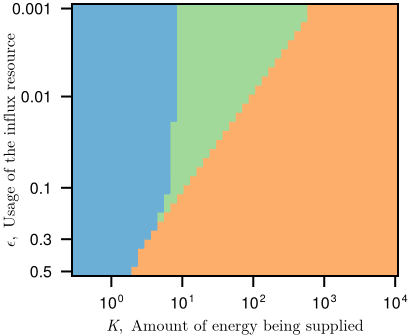

In [10]:
fig = Figure(;
    size=(double_col_width * 0.3, (double_col_width / golden_ratio) * 0.4),
    default_fig_kwargs...,
    figure_padding=(2., 5., 2., 2.),
)
ax = Axis(fig[1,1];
    xscale=log10,
)

heatmap!(ax, Ks, LeakageScale.ltox.(lis), dominant)
eps_ticks = [0.5, 0.3, 0.1, 0.01, 0.001]
ax.yticks = (LeakageScale.etox.(eps_ticks), [(@sprintf "%.2g" e) for e in eps_ticks])
ax.ylabel = L"\epsilon,\enspace\text{Usage of the influx resource}"
ax.xlabel = L"K,\enspace\text{Amount of energy being supplied}"

ax.ylabelpadding = -3.

Makie.save("../../figures/fig1/K_vs_l_pd.pdf", fig)

fig